In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6974.33it/s]


Ready!


In [2]:
def calculate_perplexity(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    logits = outputs.logits[0]
    
    losses = []
    for i in range(len(tokens) - 1):
        actual_id = inputs['input_ids'][0][i+1]
        loss = F.cross_entropy(
            logits[i].unsqueeze(0),
            actual_id.unsqueeze(0)
        ).item()
        losses.append(loss)
    
    avg_loss   = np.mean(losses)
    perplexity = np.exp(avg_loss)
    return perplexity, avg_loss

# Alag alag texts test karo
texts = [
    "The cat sat on the mat",
    "Once upon a time there was a princess",
    "Python is a popular programming language",
    "The xkqz blorp fizzled the quantum sneeze",  # Nonsense!
    "I love to eat pizza and pasta",
]

print(f"{'Text':<45} {'Perplexity':<12} {'Avg Loss'}")
print("-"*70)

for text in texts:
    ppl, loss = calculate_perplexity(text, model, tokenizer)
    print(f"{text[:44]:<45} {ppl:<12.2f} {loss:.4f}")

Text                                          Perplexity   Avg Loss
----------------------------------------------------------------------
The cat sat on the mat                        127.79       4.8504
Once upon a time there was a princess         30.49        3.4173
Python is a popular programming language      11.37        2.4311
The xkqz blorp fizzled the quantum sneeze     719.96       6.5792
I love to eat pizza and pasta                 78.29        4.3604


In [3]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# GPT2 small vs GPT2 medium
models_to_test = {
    "GPT2-small":  "gpt2",
    "GPT2-medium": "gpt2-medium",
}

test_text = "The quick brown fox jumps over the lazy dog"

print(f"Text: {test_text}\n")
print(f"{'Model':<15} {'Perplexity':<12} {'Avg Loss'}")
print("-"*40)

for model_name, model_id in models_to_test.items():
    tok = GPT2Tokenizer.from_pretrained(model_id)
    mod = GPT2LMHeadModel.from_pretrained(model_id)
    mod.eval()
    
    ppl, loss = calculate_perplexity(test_text, mod, tok)
    print(f"{model_name:<15} {ppl:<12.2f} {loss:.4f}")

Text: The quick brown fox jumps over the lazy dog

Model           Perplexity   Avg Loss
----------------------------------------


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6895.00it/s]


GPT2-small      227.28       5.4262


c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\devuser3\.cache\huggingface\hub\models--gpt2-medium. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 292/292 [00:00<00:00, 5019.37it/s]


GPT2-medium     6.72         1.9054


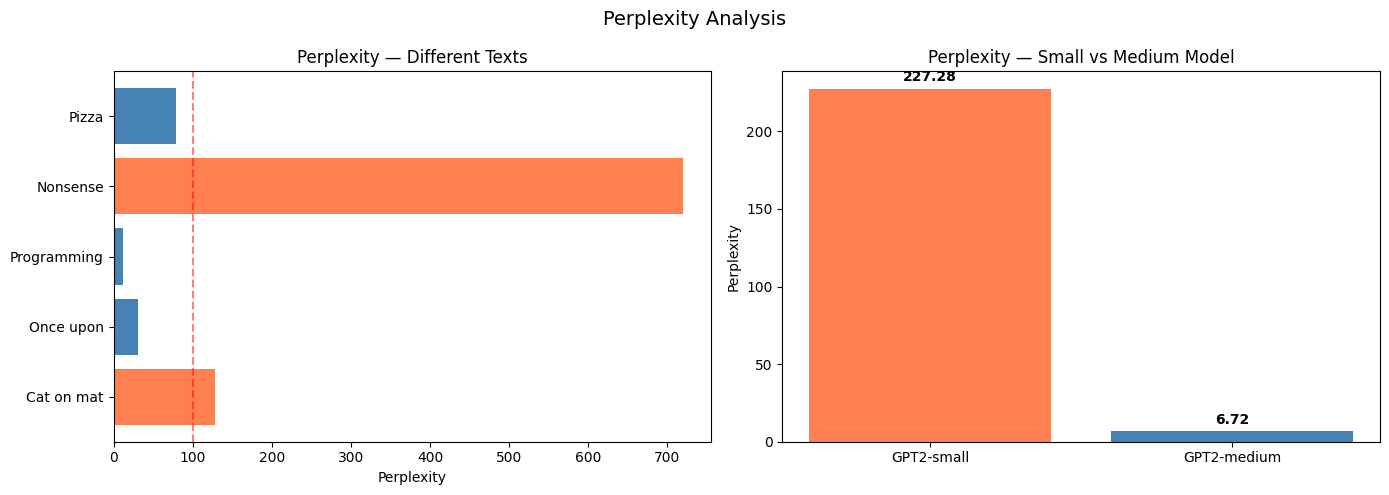

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Different texts perplexity
texts_short = ["Cat on mat", "Once upon", 
               "Programming", "Nonsense", "Pizza"]
perplexities = [127.79, 30.49, 11.37, 719.96, 78.29]
colors = ["coral" if p > 100 else "steelblue" 
          for p in perplexities]

axes[0].barh(texts_short, perplexities, color=colors)
axes[0].set_xlabel("Perplexity")
axes[0].set_title("Perplexity — Different Texts")
axes[0].axvline(x=100, color="red", 
                linestyle="--", alpha=0.5)

# Models comparison
model_names = ["GPT2-small", "GPT2-medium"]
model_ppls  = [227.28, 6.72]

axes[1].bar(model_names, model_ppls, 
            color=["coral", "steelblue"])
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity — Small vs Medium Model")

for i, ppl in enumerate(model_ppls):
    axes[1].text(i, ppl + 5, f"{ppl:.2f}", 
                 ha="center", fontweight="bold")

plt.suptitle("Perplexity Analysis", fontsize=14)
plt.tight_layout()
plt.show()

* **Perplexity** (Perplexity) is calculated as:
  **PPL = e^(average loss)** — it measures how **confused the model is**.

* **Low perplexity** → **better model performance** (more confident and accurate predictions).

* **Nonsense text** leads to **very high perplexity** (e.g., **719**), because the model cannot find meaningful patterns.

* Models with **more parameters** generally achieve **lower perplexity**.

* GPT-2 Medium (**6.72**) performs much better than GPT-2 Small (**227**) — about **34× improvement**.
